# FxNet Baseline Training

This notebook implements the baseline audio effect classification pipeline using the convolutional **FxNet** architecture on the GUITAR-FX dataset.

## 1. Setup & Imports

Load dependencies, project utilities, and hardware acceleration drivers.

In [1]:
import os
import sys
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output

# Ensure project root is in sys.path when running from notebooks/
sys.path.append('..')
from src.data.dataset import FxDataset
from src.data.datasplit import DataSplit
from src.models.fxnet import FxNet
from src.utils.metrics import compute_metrics, plot_confusion_matrix
from src.utils.device import get_device

# Enable inline plotting
%matplotlib inline


## 2. Configuration

Select the dataset scenario (`mono_disc`, `mono_cont`, `poly_disc`, or `poly_cont`) and hyperparameters.

In [2]:
# --- SCENARIO SELECTOR ---
# 'mono_disc' | 'mono_cont' | 'poly_disc' | 'poly_cont'
DATASET_TYPE = 'mono_disc'

# Global hyperparameters
SEED = 42
EPOCHS = 30
BATCH_SIZE = 100
LEARNING_RATE = 0.001
# Set to None for automatic hardware detection (AMD GPU via DirectML or NVIDIA via CUDA)
# Or force explicitly: 'dml' (AMD on Windows), 'cuda', or 'cpu'
DEVICE_NAME = None
NUM_WORKERS = 0
CACHE_IN_RAM = True

# Scenario-specific dataset root and parameters
if DATASET_TYPE == 'mono_disc':
    DATASET_ROOT = '../../datasets/GUITAR-FX-DIST/Mono_Discrete'
    EXCL_FOLDERS = ['MT2']
elif DATASET_TYPE == 'mono_cont':
    DATASET_ROOT = '../../datasets/GUITAR-FX-DIST/Mono_Continuous'
    EXCL_FOLDERS = ['MT2']
elif DATASET_TYPE == 'poly_disc':
    DATASET_ROOT = '../../datasets/GUITAR-FX-DIST/Poly_Discrete'
    EXCL_FOLDERS = ['MT2']
elif DATASET_TYPE == 'poly_cont':
    DATASET_ROOT = '../../datasets/GUITAR-FX-DIST/Poly_Continuous'
    EXCL_FOLDERS = ['MT2']
else:
    raise ValueError(f"Unknown DATASET_TYPE: {DATASET_TYPE}")

SPECTRA_FOLDER = 'mel_22050_1024_512'

# Output directories
CHECKPOINTS_DIR = "../checkpoints"
RESULTS_DIR = "../results"

os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"[{DATASET_TYPE.upper()}] Configuration loaded.")
print(f"-> ROOT: {DATASET_ROOT}")


[MONO_DISC] Configuration loaded.
-> ROOT: ../../datasets/GUITAR-FX-DIST/Mono_Discrete


## 3. Data Loading & Splitting

Initialize dataset, inspect class distribution, and split into train, validation, and test subsets.

In [3]:
device = get_device(DEVICE_NAME)
print(f"Selected compute device: {device}")

print("Loading dataset...")
dataset = FxDataset(
    root=DATASET_ROOT,
    excl_folders=EXCL_FOLDERS,
    spectra_folder=SPECTRA_FOLDER,
    cache_in_ram=CACHE_IN_RAM,
)
dataset.init_dataset()

print(f"Total dataset samples: {len(dataset):,}")
print(f"Number of effect classes: {dataset.num_fx}")

split = DataSplit(
    dataset,
    test_train_split=0.8,
    val_train_split=0.1,
    shuffle=True,
    seed=SEED,
)

train_loader, val_loader, test_loader = split.get_split(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
)

print(f"Data Split -> Train: {len(split.train_sampler):,} | Val: {len(split.val_indices):,} | Test: {len(split.test_indices):,}")


Selected compute device: privateuseone:0
Loading dataset...
Total dataset samples: 123,552
Number of effect classes: 13
Data Split -> Train: 88,956 | Val: 9,885 | Test: 24,711


## 4. Model Instantiation

Configure FxNet, CrossEntropy loss, and optimizer (with DirectML GPU support for AMD on Windows).

In [4]:
class DirectMLAdam(optim.Optimizer):
    """Adam optimizer using basic ops natively supported on DirectML GPU."""
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            lr = group["lr"]
            eps = group["eps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad
                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)
                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                state["step"] += 1
                bias_correction1 = 1.0 - (beta1 ** state["step"])
                bias_correction2 = 1.0 - (beta2 ** state["step"])

                exp_avg.mul_(beta1).add_(grad, alpha=1.0 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1.0 - beta2)
                denom = (exp_avg_sq.sqrt() / (bias_correction2 ** 0.5)).add_(eps)
                step_size = lr / bias_correction1
                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

model = FxNet(n_classes=dataset.num_fx).to(device)

if "privateuseone" in str(device) or "dml" in str(device):
    optimizer = DirectMLAdam(model.parameters(), lr=LEARNING_RATE)
else:
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
criterion = nn.CrossEntropyLoss()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"FxNet initialized with {trainable_params:,} trainable parameters.")


FxNet initialized with 762,217 trainable parameters.


## 5. Training

Execute epoch iterations, monitor loss and accuracy, and checkpoint the best-performing model.

In [5]:
best_val_acc = 0.0
epoch_times = []
train_losses, val_losses = [], []
train_accs, val_accs = [], []

total_start_time = time.time()
best_checkpoint_path = os.path.join(CHECKPOINTS_DIR, f"best_model_{DATASET_TYPE}.pt")

for epoch in range(EPOCHS):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_idx, data in enumerate(train_loader):
        if data is None: continue
        inputs, labels, _, _, _ = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct_train += preds.eq(labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / max(total_train, 1)
    train_acc = (correct_train / max(total_train, 1)) * 100
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation phase
    model.eval()
    val_loss_total = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_idx, data in enumerate(val_loader):
            if data is None: continue
            inputs, labels, _, _, _ = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item() * inputs.size(0)

            preds = outputs.argmax(dim=1)
            correct_val += preds.eq(labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss_total / max(total_val, 1)
    val_acc = (correct_val / max(total_val, 1)) * 100
    
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    epoch_duration = time.time() - epoch_start
    epoch_times.append(epoch_duration)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] ({epoch_duration:.2f}s) | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"  -> Best model saved (Val Acc: {val_acc:.2f}%)")

total_duration = time.time() - total_start_time
avg_epoch_time = sum(epoch_times) / max(len(epoch_times), 1)

print("=" * 60)
print(f"TRAINING COMPLETED in {total_duration/60:.2f} minutes.")
print(f"Average time per epoch: {avg_epoch_time:.2f} seconds.")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("=" * 60)


Epoch [01/30] (111.53s) | Train Loss: 0.7504 Acc: 70.89% | Val Loss: 0.6340 Acc: 72.57%
  -> Best model saved (Val Acc: 72.57%)
Epoch [02/30] (16.01s) | Train Loss: 0.3492 Acc: 82.57% | Val Loss: 0.3117 Acc: 83.25%
  -> Best model saved (Val Acc: 83.25%)
Epoch [03/30] (16.02s) | Train Loss: 0.2847 Acc: 84.59% | Val Loss: 0.3054 Acc: 83.97%
  -> Best model saved (Val Acc: 83.97%)
Epoch [04/30] (16.00s) | Train Loss: 0.2582 Acc: 85.40% | Val Loss: 0.2974 Acc: 83.26%
Epoch [05/30] (16.02s) | Train Loss: 0.2386 Acc: 86.06% | Val Loss: 1.7757 Acc: 55.77%
Epoch [06/30] (16.01s) | Train Loss: 0.2293 Acc: 86.23% | Val Loss: 0.3399 Acc: 82.61%
Epoch [07/30] (16.07s) | Train Loss: 0.2193 Acc: 86.71% | Val Loss: 0.3151 Acc: 83.17%
Epoch [08/30] (16.03s) | Train Loss: 0.2135 Acc: 87.00% | Val Loss: 0.2448 Acc: 86.32%
  -> Best model saved (Val Acc: 86.32%)
Epoch [09/30] (16.05s) | Train Loss: 0.2106 Acc: 87.18% | Val Loss: 0.2279 Acc: 86.28%
Epoch [10/30] (16.08s) | Train Loss: 0.2042 Acc: 87.47% 

### Training Metrics Plot

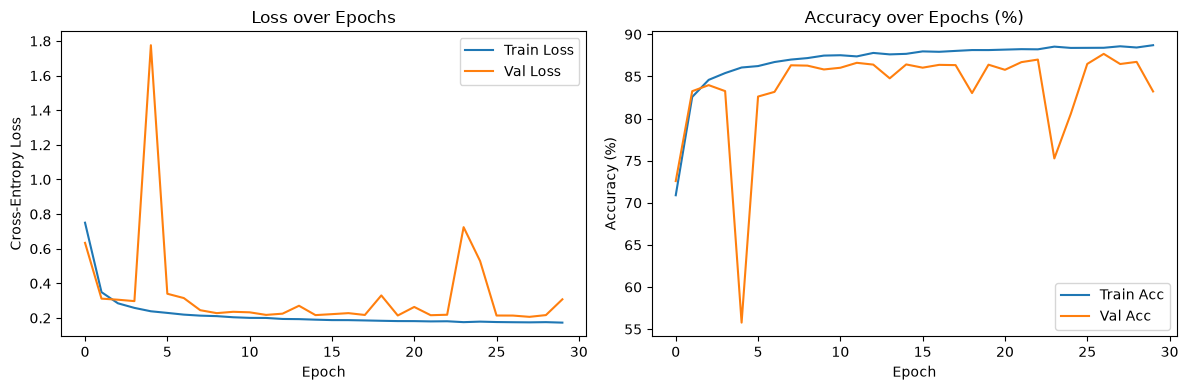

In [6]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy over Epochs (%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()


## 6. Evaluation (Test Set)

Assess final performance on the test set and visualize confusion matrices.

Loading best model checkpoint from ../checkpoints\best_model_mono_disc.pt


C:\Users\caduo\AppData\Local\Temp\ipykernel_7000\2229254297.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_checkpoint_path, map_lo

FINAL TEST RESULTS:
Test Accuracy:   86.97%
Test F1-Score:   82.99%
Macro Precision: 83.31%
Macro Recall:    85.25%


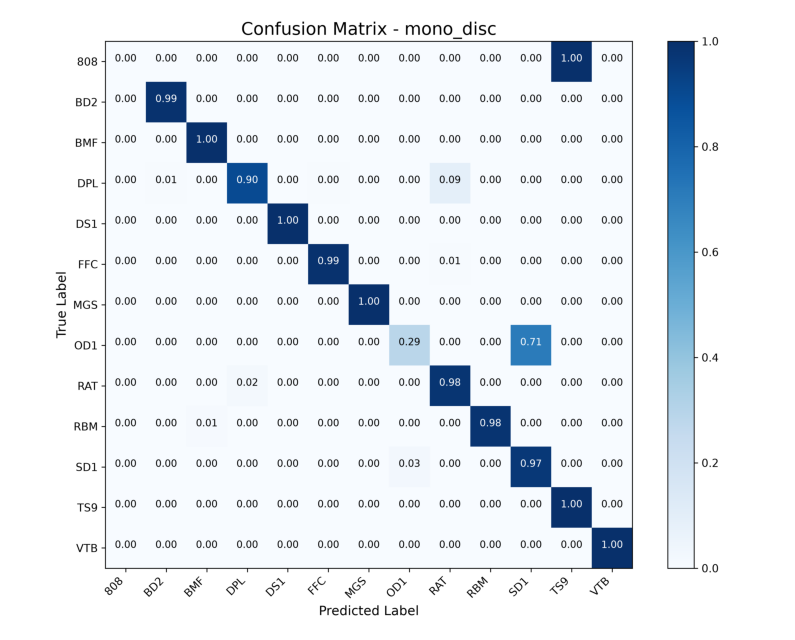

In [7]:
# Load best checkpoint weights
if os.path.exists(best_checkpoint_path):
    print(f"Loading best model checkpoint from {best_checkpoint_path}")
    model.load_state_dict(torch.load(best_checkpoint_path, map_location=device))

model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for batch_idx, data in enumerate(test_loader):
        if data is None: continue
        inputs, labels, _, _, _ = data
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

class_names = [dataset.label_to_fx[i] for i in range(dataset.num_fx)]
test_metrics = compute_metrics(test_targets, test_preds, class_names=class_names)

print("=" * 60)
print("FINAL TEST RESULTS:")
print(f"Test Accuracy:   {test_metrics['accuracy']*100:.2f}%")
print(f"Test F1-Score:   {test_metrics['macro_f1']*100:.2f}%")
print(f"Macro Precision: {test_metrics['macro_precision']*100:.2f}%")
print(f"Macro Recall:    {test_metrics['macro_recall']*100:.2f}%")
print("=" * 60)

# Confusion Matrix
cm_path = os.path.join(RESULTS_DIR, f"confusion_matrix_{DATASET_TYPE}.png")
plot_confusion_matrix(
    test_metrics["confusion_matrix"],
    classes=class_names,
    save_path=cm_path,
    normalize=True,
    title=f"Confusion Matrix - {DATASET_TYPE}",
)

# Display generated confusion matrix plot
import matplotlib.image as mpimg
if os.path.exists(cm_path):
    img = mpimg.imread(cm_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
